# 00 · Time-series data and reproducible setup

Start with what was observed: daily values, instantaneous measurements, annual peaks, and paired field measurements represent different sampling processes.

**Execution:** the default walkthrough reads checked saved app results, so it needs no live download or MCMC run.
Install this repository and the shared `bestfit-plots` package as described in the [README](../README.md).
To repeat an analysis, first build the pinned .NET runtime, set `RUN_ANALYSES = True`, and run the notebook in a fresh kernel.
The rerun retains the source priors, seeds, sampling settings and probability ordinates; receipts are saved under `output/reruns/`.

In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd() if (Path.cwd() / "runtime-lock.json").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))
import json
import pandas as pd
from IPython.display import display
from bestfit_examples.project_data import load_project
from bestfit_examples.data import input_inventory, series_inventory
from bestfit_examples.results import saved_case
from bestfit_examples.presentation import (case_metrics, case_provenance, compare_frequency,
    composite_weights, trend_ownership, uncertain_observations)
%matplotlib inline
RUN_ANALYSES = False  # True: rerun the saved analysis and its dependencies at full original settings.

## Frozen USGS imports
The app's `usgs-download-example.bestfit` contains eight series. Daily discharge is a daily summary;
instantaneous discharge describes conditions at a timestamp; an annual peak is the largest observed event in a year.
Measured stage and discharge are separate field series used to develop a rating curve after an explicit timestamp join.
This source stores 939 stage records and 412 discharge records; calling every stored row a pair would be incorrect.
These distinctions determine which later analysis is appropriate.

In [2]:
PROJECT = "usgs-download-example"
project = load_project(PROJECT)
display(series_inventory(project))
print("Source:", project["source"]["relative_path"])
print("SHA256:", project["source"]["sha256"])

,Series,Route,Type,Unit,Records,Start,End,Missing
0,USGS - 01134500 - Daily Discharge,USGS,DailyDischarge,Flow (cfs),29050,1947-01-01T00:00:00.0000000,2026-07-14T00:00:00.0000000,0
1,USGS - 07010000 - Daily Stage,USGS,DailyStage,Value,15994,1982-10-01T00:00:00.0000000,2026-07-15T00:00:00.0000000,197
2,USGS - 01646500 - Instantaneous Discharge,USGS,InstantaneousDischarge,Flow (cfs),1272826,1972-06-09T01:00:00.0000000,2026-07-15T14:50:00.0000000,0
3,USGS - 01646500 - Instantaneous Stage,USGS,InstantaneousStage,Stage (ft),723856,2007-10-01T01:00:00.0000000,2026-07-15T14:50:00.0000000,0
4,USGS - 01570500 - Measured Discharge,USGS,MeasuredDischarge,Flow (cfs),412,1897-03-31T05:00:00.0000000Z,2026-07-15T15:21:11.0000000Z,0
5,USGS - 01570500 - Measured Stage,USGS,MeasuredStage,Stage (ft),939,1897-03-31T05:00:00.0000000Z,2026-07-15T15:21:11.0000000Z,0
6,USGS - 01614000 - Peak Discharge,USGS,PeakDischarge,Flow (cfs),69,1929-04-17T00:00:00.0000000,2025-05-14T00:00:00.0000000,0
7,USGS - 01614000 - Peak Stage,USGS,PeakStage,Stage (ft),69,1929-04-17T00:00:00.0000000,2025-05-14T00:00:00.0000000,0


Source: examples/1-time-series-data/1-usgs-download/usgs-download-example.bestfit
SHA256: bf48bf775c9ab88ad7135e5d0c45be5d08ad303eb0e95aa9e120ab17adf56921


## Daily discharge and seasonality
The Moose River daily record shows the observations available for block-maxima extraction.
The seasonality view uses the app's monthly summaries. Its bands describe the spread of monthly observations;
the app labels these bands “Confidence Interval.” They are not uncertainty bounds for a fitted flood-frequency curve.

,Setting,Saved choice
0,UnitLabel,Flow (cfs)
1,EntryMethod,USGS
2,SeriesType,DailyDischarge


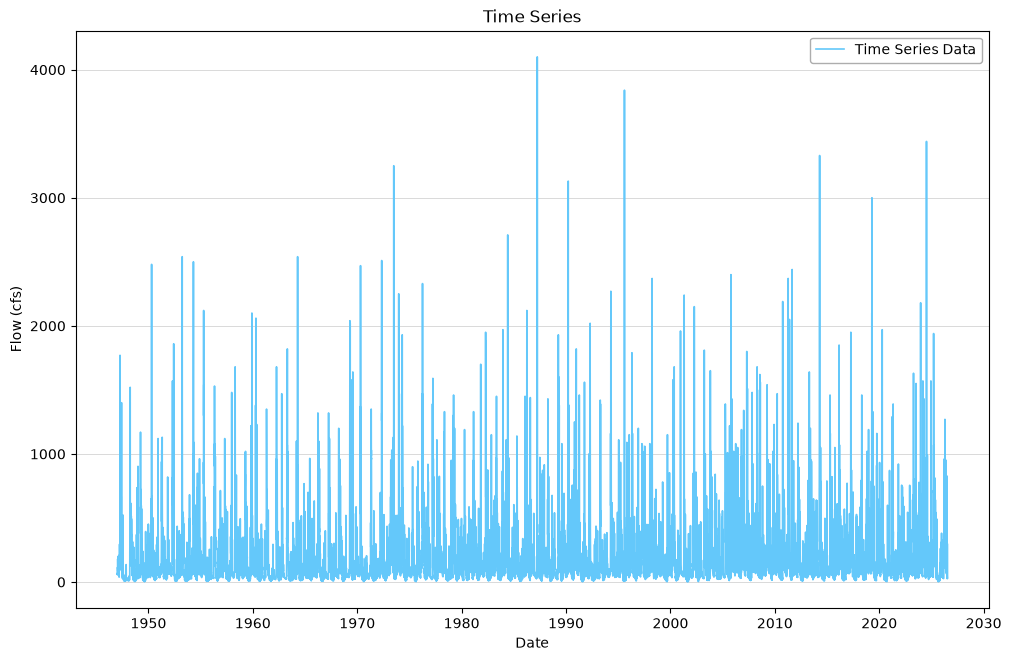

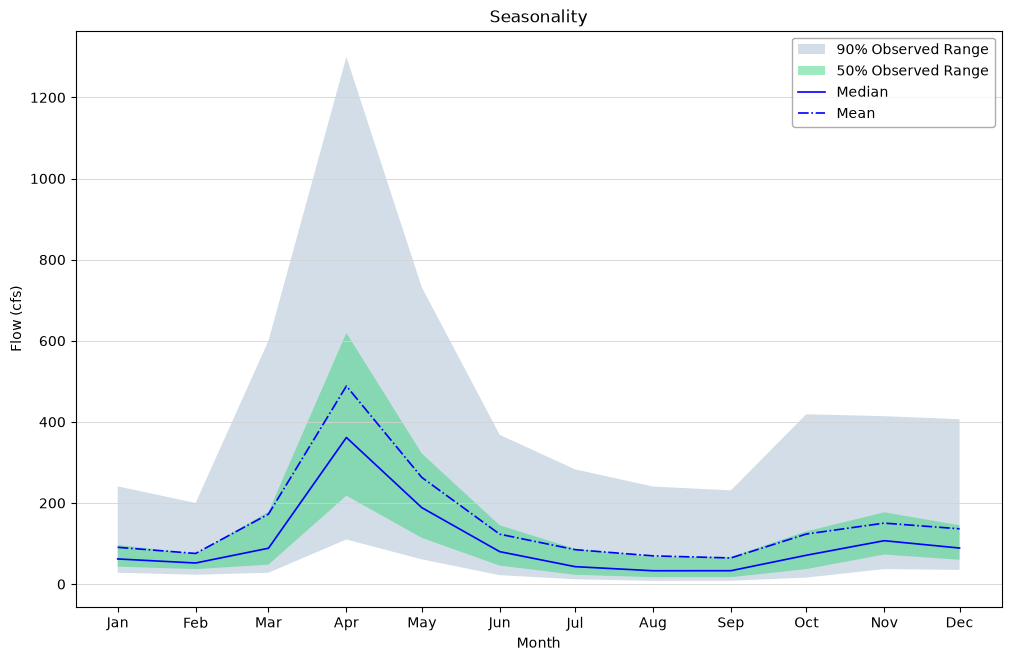

In [3]:
daily = saved_case(PROJECT, "USGS - 01134500 - Daily Discharge")
display(daily.settings)
daily.show("series")
daily.show("seasonality")

## Annual peaks and other import routes
Peak seasonality is a monthly event-frequency histogram. ACF/PACF views keep the app's missing-data guard;
a gap is not treated as a zero or silently interpolated.
The app also supplies GHCN precipitation, CHMN, HEC-DSS and manual-entry projects in this repository's frozen source inventory.
The ABOM example remains linked from the app's `examples/1-time-series-data` folder; online imports are optional updates, not prerequisites for this walkthrough.

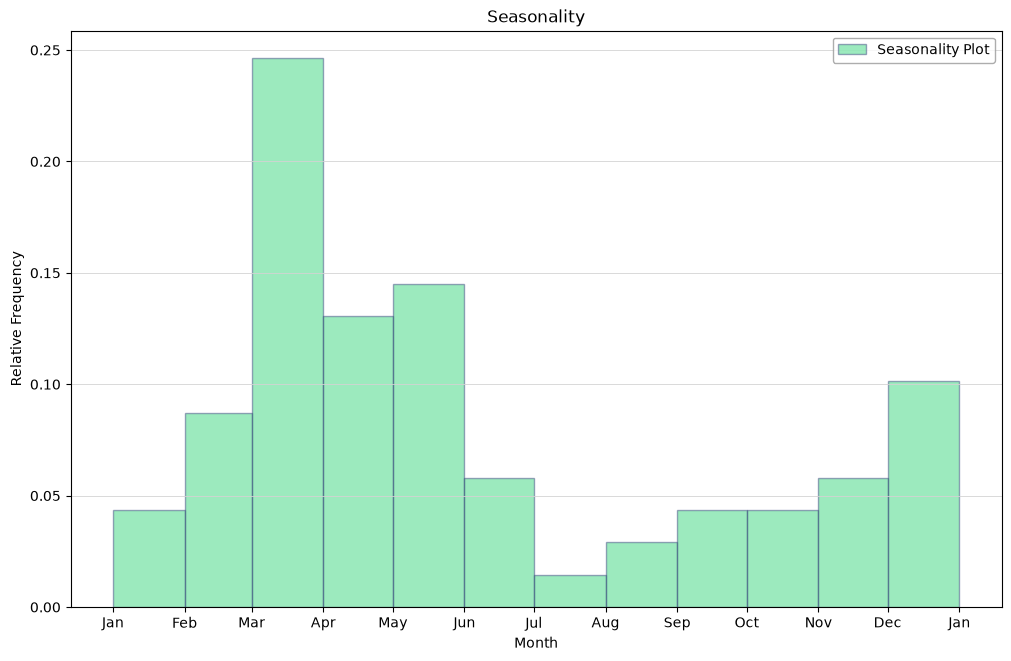

,Series,Route,Type,Unit,Records,Start,End,Missing,Project
0,GHCN - USC00040741 - Daily Precipitation,GHCN,DailyPrecipitation,Precipitation (in),24106,1960-07-01T00:00:00.0000000,2026-06-30T00:00:00.0000000,482,ghcn-download-example
1,GHCN - USC00046685 - Daily Snow,GHCN,DailySnow,Snow (in),23772,1957-05-01T00:00:00.0000000,2022-05-31T00:00:00.0000000,2197,ghcn-download-example
2,CHMN - 08MG005 - Daily Discharge,CHMN,DailyDischarge,Flow (cms),40594,1914-01-01T00:00:00.0000000,2025-02-20T00:00:00.0000000,2656,chmn-download-example
3,CHMN - 08MG005 - Daily Stage,CHMN,DailyStage,Stage (m),5097,2011-03-10T00:00:00.0000000,2025-02-20T00:00:00.0000000,159,chmn-download-example
4,CHMN - 08MG005 - Instantaneous Discharge,CHMN,InstantaneousDischarge,Flow (cms),157213,2025-01-15T19:25:00.0000000,2026-07-15T18:35:00.0000000,0,chmn-download-example
5,CHMN - 08MG005 - Instantaneous Stage,CHMN,InstantaneousStage,Stage (m),157213,2025-01-15T19:25:00.0000000,2026-07-15T18:35:00.0000000,0,chmn-download-example
6,CHMN - 08MG005 - Peak Discharge,CHMN,PeakDischarge,Flow (cms),64,1949-08-17T15:15:00.0000000,2024-01-30T08:45:00.0000000,0,chmn-download-example
7,CHMN - 08MG005 - Peak Stage,CHMN,PeakStage,Stage (m),13,2012-07-17T05:20:00.0000000,2024-01-30T08:45:00.0000000,0,chmn-download-example
8,Grapevine Dam - Inflow,HECDSS,DailyDischarge,CFS,2785,2007-03-16T00:00:00.0000000,2007-07-10T00:00:00.0000000,0,hec-dss-import-example
9,Grapevine Dam - Outflow,HECDSS,DailyDischarge,CFS,2785,2007-03-16T00:00:00.0000000,2007-07-10T00:00:00.0000000,0,hec-dss-import-example


In [4]:
peaks = saved_case(PROJECT, "USGS - 01614000 - Peak Discharge")
peaks.show("seasonality")
routes = ["ghcn-download-example", "chmn-download-example", "hec-dss-import-example", "manual-entry-example"]
display(pd.concat([series_inventory(load_project(slug)).assign(Project=slug) for slug in routes], ignore_index=True))

**Next:** notebook 01 turns the observed records into analysis inputs while retaining dates, units and historical information.